# Proyecto Precálculo — regresión lineal base

Este notebook construye el modelo lineal base para predecir `nota_primer_parcial`. Se organiza en dos etapas y conserva el criterio de separación definido en los entregables previos:

1. **Preprocesamiento:** auditoría de reglas de negocio, definición de variables, imputación, transformaciones, tratamiento de outliers y codificación dentro de un Pipeline.
2. **Modelo Base:** línea base trivial, SVM de regresión con formulación lineal, validación cruzada, evaluación independiente, intervalos bootstrap, diagnóstico de residuos, curva de aprendizaje e interpretación de coeficientes.

La partición train/test ya fue construida antes de la aumentación, agrupando por estudiante y estratificando por bins del promedio de la nota. Por tanto, este notebook no vuelve a mezclar las particiones. Todas las estadísticas aprendibles del preprocesamiento se ajustan únicamente dentro de cada partición de entrenamiento o de cada fold.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVR

import statsmodels.api as sm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_breuschpagan

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 100)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
TARGET = 'nota_primer_parcial'
EXCLUDED_FROM_MODEL = ['nota_final']
BUSINESS_RULE_COLUMNS = [
    'Dominio_Final',
    'Dominio_Inicial',
    'Tiempo_Total_Tiempo',
    'Tiempo_total_Aprendidos_hora',
]

def locate_data_file(filename):
    candidates = [Path(filename), Path('Precalculo') / filename]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'No se encontró {filename}. Rutas revisadas: {candidates}')

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', drop='first', sparse=False)

print(f'Objetivo: {TARGET}')
print(f'Estado: configuración reproducible con semilla {RANDOM_STATE}')

Objetivo: nota_primer_parcial
Estado: configuración reproducible con semilla 42


## Etapa 1. Preprocesamiento

### 1.1 Auditoría inicial y exclusión de registros no válidos

El EDA comprehensivo identificó 58 registros del train que incumplen reglas de consistencia del proceso académico. Estas filas no se consideran faltantes convencionales: la inconsistencia afecta la validez sustantiva del registro y por eso se excluye antes de calcular estadísticas o ajustar cualquier transformación.

Las reglas son:

- `Dominio_Final >= Dominio_Inicial`.
- Si `Tiempo_Total_Tiempo = 0`, entonces `Dominio_Final = Dominio_Inicial`.
- Si `Tiempo_total_Aprendidos_hora = 0`, entonces `Dominio_Final = Dominio_Inicial`.

Se auditan ambos archivos. El train debe reproducir las 58 exclusiones documentadas por el EDA; si el test contiene otras filas que incumplen las mismas reglas, también se retiran de la evaluación para que el desempeño corresponda a registros válidos. Los CSV originales no se sobrescriben.

In [2]:
TRAIN_PATH = locate_data_file('Datos_Aleks_Augmented_30000_r_2_train.csv')
TEST_PATH = locate_data_file('Datos_Aleks_Augmented_30000_r_2_test.csv')

df_train_raw = pd.read_csv(TRAIN_PATH, sep=';', decimal=',', encoding='utf-8-sig')
df_test_raw = pd.read_csv(TEST_PATH, sep=';', decimal=',', encoding='utf-8-sig')

required_columns = [TARGET, *EXCLUDED_FROM_MODEL, *BUSINESS_RULE_COLUMNS]
for name, frame in [('train', df_train_raw), ('test', df_test_raw)]:
    missing = [column for column in required_columns if column not in frame.columns]
    if missing:
        raise ValueError(f'Faltan columnas requeridas en {name}: {missing}')
    for column in [TARGET, *BUSINESS_RULE_COLUMNS]:
        frame[column] = pd.to_numeric(frame[column], errors='coerce')
    if frame[TARGET].isna().any():
        raise ValueError(f'{name} contiene valores faltantes o no numéricos en {TARGET}')

if list(df_train_raw.columns) != list(df_test_raw.columns):
    raise ValueError('Train y test no tienen exactamente el mismo esquema')

def audit_business_rules(frame):
    business = frame[BUSINESS_RULE_COLUMNS].copy()
    domain_pair_available = business['Dominio_Final'].notna() & business['Dominio_Inicial'].notna()
    business['regla_dominio_final_mayor_o_igual'] = (
        ~domain_pair_available | business['Dominio_Final'].ge(business['Dominio_Inicial'])
    )
    total_zero = business['Tiempo_Total_Tiempo'].notna() & business['Tiempo_Total_Tiempo'].eq(0)
    learned_zero = business['Tiempo_total_Aprendidos_hora'].notna() & business['Tiempo_total_Aprendidos_hora'].eq(0)
    same_domain = business['Dominio_Final'].eq(business['Dominio_Inicial'])
    business['regla_tiempo_total_cero'] = ~total_zero | same_domain
    business['regla_tiempo_aprendidos_cero'] = ~learned_zero | same_domain
    business['registro_extraño'] = ~business[[
        'regla_dominio_final_mayor_o_igual',
        'regla_tiempo_total_cero',
        'regla_tiempo_aprendidos_cero',
    ]].all(axis=1)

    summary = pd.DataFrame({
        'regla': [
            'Dominio_Final >= Dominio_Inicial',
            'Tiempo_Total_Tiempo = 0 implica igualdad de dominios',
            'Tiempo_total_Aprendidos_hora = 0 implica igualdad de dominios',
            'Registro extrañado: incumple al menos una regla',
        ],
        'incumplimientos': [
            int((~business['regla_dominio_final_mayor_o_igual']).sum()),
            int((~business['regla_tiempo_total_cero']).sum()),
            int((~business['regla_tiempo_aprendidos_cero']).sum()),
            int(business['registro_extraño'].sum()),
        ],
    })
    return frame.loc[~business['registro_extraño']].copy(), summary, business

df_train, train_rule_summary, train_rule_detail = audit_business_rules(df_train_raw)
df_test, test_rule_summary, test_rule_detail = audit_business_rules(df_test_raw)

if int(train_rule_detail['registro_extraño'].sum()) != 58:
    raise AssertionError(
        'El EDA documentó 48 registros inválidos en train, '
        f'pero la auditoría actual encontró {int(train_rule_detail["registro_extraño"].sum())}.'
    )

business_rule_summary = pd.DataFrame({
    'particion': ['train'] * len(train_rule_summary) + ['test'] * len(test_rule_summary),
    'regla': pd.concat([train_rule_summary['regla'], test_rule_summary['regla']], ignore_index=True),
    'incumplimientos': pd.concat([
        train_rule_summary['incumplimientos'],
        test_rule_summary['incumplimientos'],
    ], ignore_index=True),
})
display(business_rule_summary)
print(f'Train original: {len(df_train_raw):,} | excluidos por reglas: {int(train_rule_detail["registro_extraño"].sum()):,} | válido: {len(df_train):,}')
print(f'Test original:  {len(df_test_raw):,} | excluidos por reglas: {int(test_rule_detail["registro_extraño"].sum()):,} | válido: {len(df_test):,}')

,particion,regla,incumplimientos
0,train,Dominio_Final >= Dominio_Inicial,0
1,train,Tiempo_Total_Tiempo = 0 implica igualdad de dominios,0
2,train,Tiempo_total_Aprendidos_hora = 0 implica igualdad de dominios,58
3,train,Registro extrañado: incumple al menos una regla,58
4,test,Dominio_Final >= Dominio_Inicial,0
5,test,Tiempo_Total_Tiempo = 0 implica igualdad de dominios,0
6,test,Tiempo_total_Aprendidos_hora = 0 implica igualdad de dominios,37
7,test,Registro extrañado: incumple al menos una regla,37


Train original: 24,000 | excluidos por reglas: 58 | válido: 23,942
Test original:  6,000 | excluidos por reglas: 37 | válido: 5,963


**Decisión documentada.** Se eliminan las inconsistencias de negocio antes del preprocesamiento. No se imputan ni se corrigen porque una imputación podría convertir un dominio o un tiempo imposible en una observación aparentemente válida. Esta decisión reproduce la auditoría del EDA y deja intactos los outliers estadísticos que sí representan conductas observadas.

### 1.2 Roles, variables derivadas y faltantes

La variable objetivo es `nota_primer_parcial`. `nota_final` se conserva únicamente para trazabilidad y auditoría de fuga; no ingresa al modelo.

La ingeniería de características derivada de reglas de negocio se realizó en una etapa anterior. En este notebook esas variables aparecen como columnas ya construidas del dataset y no se vuelven a generar dentro del Pipeline:

- `Categoria_temas_inicial` y `Categoria_temas_final`: categorías definidas por la estructura de contenidos del curso.
- `cumplimiento_temas`: indicador de cumplimiento de la meta académica definida para la asignatura.
- `avance_cuartiles`: cuartiles de `avance_precalculo_aleks` calculados por período y asignatura.
- `Tiempo_total_Aprendidos_hora`: razón matemática basada en el avance y el tiempo total dedicado, conceptualmente `avance_precalculo_aleks / Tiempo_Total_Tiempo`, cuando el denominador es válido.

Las dos últimas tienen una parte matemática replicable, pero `avance_cuartiles` depende de los grupos período–asignatura y esos identificadores no están en el esquema final. Las categorías de temas y cumplimiento dependen de reglas del contenido del curso. Por ello, se usan como variables observadas del dataset y se documenta su procedencia; no se rederivan con información del test ni de los folds.

El EDA mostró faltantes escasos y concentrados en las dos medidas de tiempo. Se imputan dentro del Pipeline: mediana para numéricas, robusta frente a asimetría y outliers; categoría más frecuente para categóricas. Al no existir faltantes en el objetivo ni evidencia suficiente para estimar un mecanismo MAR específico, se trata la ausencia como una captura ocasional compatible con MCAR condicional a las variables observadas. Las reglas de negocio siguen siendo una etapa separada y no imputable.

In [3]:
feature_cols = [column for column in df_train.columns if column not in [TARGET, *EXCLUDED_FROM_MODEL]]
numeric_cols = df_train[feature_cols].select_dtypes(include=np.number).columns.tolist()
categorical_cols = [column for column in feature_cols if column not in numeric_cols]

missing_profile = pd.DataFrame({
    'train_nulos': df_train[feature_cols].isna().sum(),
    'train_pct_nulos': 100 * df_train[feature_cols].isna().mean(),
    'test_nulos': df_test[feature_cols].isna().sum(),
    'test_pct_nulos': 100 * df_test[feature_cols].isna().mean(),
}).sort_values('train_nulos', ascending=False)
display(missing_profile[missing_profile[['train_nulos', 'test_nulos']].sum(axis=1) > 0].round(4))

time_missing = [
    column for column in ['Tiempo_Total_Tiempo', 'Tiempo_total_Aprendidos_hora']
    if column in feature_cols
]
if time_missing:
    print('Filas train con ambos tiempos faltantes:', int(df_train[time_missing].isna().all(axis=1).sum()))
    print('Filas train con algún tiempo faltante:', int(df_train[time_missing].isna().any(axis=1).sum()))

roles = pd.DataFrame({
    'rol': ['objetivo' if c == TARGET else 'auditoría, no predictor' if c in EXCLUDED_FROM_MODEL else 'predictora' for c in df_train.columns],
    'tipo': df_train.dtypes.astype(str),
    'nulos_train': df_train.isna().sum(),
}).rename_axis('variable')
display(roles)
print(f'Predictoras: {len(feature_cols)} ({len(numeric_cols)} numéricas y {len(categorical_cols)} categóricas)')
print('Predictora excluida por fuga:', EXCLUDED_FROM_MODEL)

,train_nulos,train_pct_nulos,test_nulos,test_pct_nulos
Tiempo_empleado_en_la_verificación_de_conocimientos,413,1.7250,72,1.2074
Tiempo_total_Aprendidos_hora,63,0.2631,40,0.6708
Tiempo_Total_Tiempo,63,0.2631,40,0.6708


Filas train con ambos tiempos faltantes: 63
Filas train con algún tiempo faltante: 63


,rol,tipo,nulos_train
variable,,,
Icfes_nuevo,predictora,int64,0
Icfes_Matematicas,predictora,int64,0
Tiempo_empleado_en_la_verificación_de_conocimientos,predictora,float64,413
Dominio_Inicial,predictora,int64,0
Categoria_temas_inicial,predictora,str,0
avance_precalculo_aleks,predictora,int64,0
Dominio_Final,predictora,int64,0
Categoria_temas_final,predictora,str,0
Tiempo_Total_Tiempo,predictora,float64,63


Predictoras: 15 (8 numéricas y 7 categóricas)
Predictora excluida por fuga: ['nota_final']


### 2.1 Objetivo y partición

La respuesta es nota_primer_parcial, una calificación continua en la escala académica. Se mantienen los archivos train/test creados antes de la aumentación y se reserva el test para la evaluación final. La auditoría de generación validó la separación por estudiante: 1.184 IDs en train, 297 en test y ninguno compartido.

Para la validación cruzada interna se replica la estratificación por bins de y_train con StratifiedKFold. Como el identificador se elimina del esquema estandarizado, no es posible construir folds agrupados por estudiante dentro del train; esta limitación se considera al interpretar la validación interna.

In [4]:
X_train = df_train[feature_cols].copy()
y_train = df_train[TARGET].astype(float).copy()
X_test = df_test[feature_cols].copy()
y_test = df_test[TARGET].astype(float).copy()

if TARGET in X_train.columns or TARGET in X_test.columns:
    raise AssertionError('El objetivo no puede aparecer entre las predictoras')
if EXCLUDED_FROM_MODEL[0] in X_train.columns or EXCLUDED_FROM_MODEL[0] in X_test.columns:
    raise AssertionError('nota_final fue incluida accidentalmente en las predictoras')
if y_train.isna().any() or y_test.isna().any():
    raise AssertionError('El objetivo no puede contener faltantes')

def make_target_bins(y, n_bins=5):
    ranks = pd.Series(y).rank(method='first')
    return pd.qcut(ranks, q=n_bins, labels=False, duplicates='drop').astype(int).to_numpy()

cv_labels = make_target_bins(y_train, n_bins=5)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(cv.split(X_train, cv_labels))

partition_summary = pd.DataFrame({
    'particion': ['train válido', 'test válido'],
    'n': [len(y_train), len(y_test)],
    'media_objetivo': [y_train.mean(), y_test.mean()],
    'desv_objetivo': [y_train.std(), y_test.std()],
    'min_objetivo': [y_train.min(), y_test.min()],
    'max_objetivo': [y_train.max(), y_test.max()],
})
display(partition_summary.round(4))
print('La separación externa no se vuelve a ejecutar; el objeto CV reproduce la estratificación por bins dentro de train.')

,particion,n,media_objetivo,desv_objetivo,min_objetivo,max_objetivo
0,train válido,23942,3.5317,1.1296,0.50,5.0
1,test válido,5963,3.5280,1.1283,0.84,5.0


La separación externa no se vuelve a ejecutar; el objeto CV reproduce la estratificación por bins dentro de train.


El train válido contiene 23.942 observaciones y el test válido, 5.963. Sus promedios del objetivo son similares (3,5317 y 3,5280), con rangos de 0,50 a 5,00 y de 0,84 a 5,00, respectivamente. Esta comparación descriptiva no reemplaza la evaluación del modelo en el test.

### 2.2 Preprocesamiento dentro del Pipeline

Las decisiones se aplican únicamente al train de cada fold:

- **Imputación:** mediana para variables numéricas y categoría más frecuente para variables categóricas, de acuerdo con la baja frecuencia y concentración observada de faltantes.
- **Escalamiento:** `StandardScaler` después de imputar y, cuando corresponde, transformar; así la penalización y la geometría del SVM lineal no dependen de las unidades originales.
- **Categóricas:** one-hot con categoría desconocida ignorada y primera categoría como referencia para facilitar la lectura de coeficientes.

#### Justificación de `log1p` en las tres variables de tiempo

El EDA mostró asimetría positiva y colas derechas en `Tiempo_empleado_en_la_verificación_de_conocimientos` (asimetría = 1.7352), `Tiempo_Total_Tiempo` (1.2176) y `Tiempo_total_Aprendidos_hora` (1.3118). En estas variables la mayoría de los estudiantes se concentra en tiempos relativamente bajos, mientras que una minoría presenta valores mucho mayores. Esa forma es esperable en medidas de dedicación y hace que los valores extremos tengan un apalancamiento importante sobre un modelo lineal.

Por ello se aplica `log1p(x) = log(1 + x)`. La transformación comprime progresivamente los valores altos, reduce la influencia de las colas y permite que las diferencias relativas entre tiempos sean más representativas que las diferencias absolutas. Se utiliza `log1p` y no `log(x)` porque las variables son no negativas y pueden contener ceros: con `log1p(0) = 0` esos registros siguen siendo válidos. La transformación se ejecuta después de imputar y antes del escalamiento.

La decisión se limita a las tres medidas de tiempo porque son variables continuas de duración o productividad con una interpretación multiplicativa natural. No se aplica automáticamente a `Dominio_Inicial`, `Dominio_Final` o `avance_precalculo_aleks`: aunque algunas también presentan asimetría, son conteos discretos ligados a la progresión curricular y contienen ceros estructurales; transformarlas con logaritmo podría dificultar la interpretación de las reglas del curso. Las variables Icfes se mantienen en su escala y solo se estandarizan.

El modelo no transforma la variable objetivo: la nota se conserva en su escala original para que RMSE, MAPE y R² sean interpretables académicamente.

In [5]:
log_numeric_cols = [
    column for column in [
        'Tiempo_empleado_en_la_verificación_de_conocimientos',
        'Tiempo_Total_Tiempo',
        'Tiempo_total_Aprendidos_hora',
    ] if column in numeric_cols
]
plain_numeric_cols = [column for column in numeric_cols if column not in log_numeric_cols]

numeric_log_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler()),
])
numeric_plain_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', make_ohe()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num_log', numeric_log_pipeline, log_numeric_cols),
        ('num_plain', numeric_plain_pipeline, plain_numeric_cols),
        ('cat', categorical_pipeline, categorical_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=True,
)

def make_dummy_pipeline():
    return Pipeline(steps=[
        ('preprocesamiento', clone(preprocessor)),
        ('modelo', DummyRegressor(strategy='mean')),
    ])

def make_linear_svm_pipeline():
    return Pipeline(steps=[
        ('preprocesamiento', clone(preprocessor)),
        ('modelo', LinearSVR(
            C=1.0,
            epsilon=0.1,
            loss='epsilon_insensitive',
            max_iter=20000,
            random_state=RANDOM_STATE,
        )),
    ])

dummy_pipeline = make_dummy_pipeline()
linear_svm_pipeline = make_linear_svm_pipeline()
print('Variables con log1p:', log_numeric_cols)
print('Variables numéricas sin log1p:', plain_numeric_cols)
print('SVM: LinearSVR, equivalente a una regresión ε-insensible con kernel lineal en el espacio transformado.')

Variables con log1p: ['Tiempo_empleado_en_la_verificación_de_conocimientos', 'Tiempo_Total_Tiempo', 'Tiempo_total_Aprendidos_hora']
Variables numéricas sin log1p: ['Icfes_nuevo', 'Icfes_Matematicas', 'Dominio_Inicial', 'avance_precalculo_aleks', 'Dominio_Final']
SVM: LinearSVR, equivalente a una regresión ε-insensible con kernel lineal en el espacio transformado.


In [6]:
dummy_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_log', ...), ('num_plain', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: floa

In [7]:
linear_svm_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_log', ...), ('num_plain', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: floa

El Pipeline imputa las variables numéricas con la mediana y las categóricas con la categoría más frecuente; aplica log1p a las tres medidas de tiempo, estandariza las numéricas y codifica las categóricas con one-hot. El preprocesamiento se ajusta dentro de cada fold. Los valores extremos válidos se conservan, y la nota objetivo no se transforma.

### 2.3 Línea base trivial y validación cruzada

La línea base es `DummyRegressor(strategy="mean")`: predice la media del objetivo del train en cada fold. El SVM lineal utiliza exactamente el mismo preprocesamiento y se valida con los mismos cinco folds estratificados. Las métricas negativas propias de los scorers de sklearn se convierten a escala positiva al presentar los resultados.

In [8]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape_percent(y_true, y_pred):
    return float(100 * mean_absolute_percentage_error(y_true, y_pred))

scoring = {
    'RMSE': make_scorer(rmse, greater_is_better=False),
    'MAPE': make_scorer(mape_percent, greater_is_better=False),
    'R2': make_scorer(r2_score),
}

def cross_validation_summary(name, estimator):
    result = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv_splits,
        scoring=scoring,
        return_train_score=True,
        n_jobs=1,
    )
    rows = []
    for metric in ['RMSE', 'MAPE', 'R2']:
        sign = -1 if metric in ['RMSE', 'MAPE'] else 1
        rows.append({
            'modelo': name,
            'metrica': metric,
            'media_cv': sign * result[f'test_{metric}'].mean(),
            'desv_cv': result[f'test_{metric}'].std(),
            'media_train_cv': sign * result[f'train_{metric}'].mean(),
        })
    return pd.DataFrame(rows), result

dummy_cv_table, dummy_cv_raw = cross_validation_summary('Dummy media', dummy_pipeline)
linear_cv_table, linear_cv_raw = cross_validation_summary('SVM lineal', linear_svm_pipeline)
cv_table = pd.concat([dummy_cv_table, linear_cv_table], ignore_index=True)
display(cv_table.round(4))

,modelo,metrica,media_cv,desv_cv,media_train_cv
0,Dummy media,RMSE,1.1296,0.0040,1.1296
1,Dummy media,MAPE,38.0128,0.3479,38.0127
2,Dummy media,R2,-0.0000,0.0000,0.0000
3,SVM lineal,RMSE,0.8001,0.0058,0.7981
4,SVM lineal,MAPE,23.2376,0.0941,23.1648
5,SVM lineal,R2,0.4981,0.0100,0.5008


En los cinco folds, el SVM obtuvo RMSE medio de 0,8001, MAPE de 23,2376 % y R² de 0,4981; la referencia Dummy obtuvo RMSE de 1,1296, MAPE de 38,0128 % y R² cercano a cero. La brecha entre el RMSE medio de entrenamiento (0,7981) y validación (0,8001) es pequeña, sin una señal marcada de sobreajuste dentro de los folds. La comparación final se realiza en el test reservado.

### 2.4 Ajuste final y evaluación en test

Después de seleccionar el procedimiento —sin búsqueda de hiperparámetros en este notebook— cada Pipeline se ajusta con todo el train válido. La evaluación final se calcula en el test válido, que permaneció separado durante todo el preprocesamiento. La comparación con Dummy responde si el modelo lineal aprende señal por encima de la referencia mínima.

In [9]:
dummy_pipeline.fit(X_train, y_train)
linear_svm_pipeline.fit(X_train, y_train)

predictions = {
    'Dummy media': dummy_pipeline.predict(X_test),
    'SVM lineal': linear_svm_pipeline.predict(X_test),
}

def evaluate_predictions(y_true, y_pred, name):
    return {
        'modelo': name,
        'RMSE': rmse(y_true, y_pred),
        'MAPE_%': mape_percent(y_true, y_pred),
        'R2': float(r2_score(y_true, y_pred)),
        'MAE': float(np.mean(np.abs(y_true - y_pred))),
    }

test_metrics = pd.DataFrame([
    evaluate_predictions(y_test, pred, name)
    for name, pred in predictions.items()
]).set_index('modelo')
display(test_metrics.round(4))

improvement = pd.Series({
    'reducción_RMSE_vs_dummy_%': 100 * (test_metrics.loc['Dummy media', 'RMSE'] - test_metrics.loc['SVM lineal', 'RMSE']) / test_metrics.loc['Dummy media', 'RMSE'],
    'reducción_MAPE_vs_dummy_%': 100 * (test_metrics.loc['Dummy media', 'MAPE_%'] - test_metrics.loc['SVM lineal', 'MAPE_%']) / test_metrics.loc['Dummy media', 'MAPE_%'],
    'incremento_R2_vs_dummy': test_metrics.loc['SVM lineal', 'R2'] - test_metrics.loc['Dummy media', 'R2'],
})
display(improvement.to_frame('valor').round(4))

,RMSE,MAPE_%,R2,MAE
modelo,,,,
Dummy media,1.1282,37.7330,-0.0000,0.9705
SVM lineal,0.9093,27.1489,0.3503,0.7329


,valor
reducción_RMSE_vs_dummy_%,19.3963
reducción_MAPE_vs_dummy_%,28.0499
incremento_R2_vs_dummy,0.3503


En el test, el SVM alcanza RMSE de 0,9093, MAE de 0,7329, MAPE de 27,1489 % y R² de 0,3503. Frente a Dummy, reduce RMSE en 19,40 % y MAPE en 28,05 %. El resultado confirma señal predictiva útil, aunque el desempeño es moderado y queda por debajo de la validación cruzada.

### 2.5 Intervalos de confianza por bootstrap

Se calculan intervalos de confianza percentiles del 95 % mediante bootstrap de pares —se remuestrean conjuntamente la nota observada y la predicción— sobre el test válido. Estos intervalos describen la incertidumbre de las métricas en esta muestra de evaluación; no sustituyen una validación externa adicional.

In [10]:
def bootstrap_metric_ci(y_true, y_pred, metric_function, n_boot=1000, seed=RANDOM_STATE):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rng = np.random.default_rng(seed)
    n = len(y_true)
    values = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        indices = rng.integers(0, n, size=n)
        values[i] = metric_function(y_true[indices], y_pred[indices])
    point = metric_function(y_true, y_pred)
    return point, float(np.quantile(values, 0.025)), float(np.quantile(values, 0.975))

metric_functions = {
    'RMSE': rmse,
    'MAPE_%': mape_percent,
    'R2': lambda y_true, y_pred: float(r2_score(y_true, y_pred)),
}

bootstrap_rows = []
for name, pred in predictions.items():
    for metric_name, metric_function in metric_functions.items():
        point, lower, upper = bootstrap_metric_ci(y_test, pred, metric_function)
        bootstrap_rows.append({
            'modelo': name,
            'metrica': metric_name,
            'estimación': point,
            'IC_2.5%': lower,
            'IC_97.5%': upper,
        })
bootstrap_table = pd.DataFrame(bootstrap_rows)
display(bootstrap_table.round(4))

,modelo,metrica,estimación,IC_2.5%,IC_97.5%
0,Dummy media,RMSE,1.1282,1.1126,1.1441
1,Dummy media,MAPE_%,37.7330,36.5331,39.0583
2,Dummy media,R2,-0.0000,-0.0008,-0.0000
3,SVM lineal,RMSE,0.9093,0.8929,0.9235
4,SVM lineal,MAPE_%,27.1489,26.2389,28.0514
5,SVM lineal,R2,0.3503,0.3275,0.3715


Los intervalos bootstrap del 95 % para el SVM son RMSE [0,8929; 0,9235], MAPE [26,2389 %; 28,0514 %] y R² [0,3275; 0,3715]. Los intervalos no se solapan con los de la referencia Dummy en estas métricas, lo que respalda la mejora dentro de esta muestra de prueba; no sustituye una validación externa.

### 2.6 Diagnóstico de residuos

Para el SVM lineal se inspeccionan:

- normalidad aproximada mediante histograma, gráfico Q-Q y prueba de normalidad sobre una muestra de hasta 5.000 residuos;
- heterocedasticidad mediante Breusch–Pagan y la relación entre el valor absoluto del residuo y el ajustado;
- patrón de error mediante residuos frente a predicción.

La normalidad no se usa como criterio único de validez predictiva, pero una desviación marcada afecta la interpretación de intervalos y de inferencia lineal. Un Breusch–Pagan significativo sugiere que la varianza cambia con el nivel predicho.

,normaltest_p,Breusch_Pagan_p,Spearman_abs_resid_vs_ajustado,media_residuo,desv_residuo
modelo,,,,,
Dummy media,0.0,NaN,NaN,-0.00372,1.12816
SVM lineal,0.0,0.0,-0.16658,-0.02728,0.90894


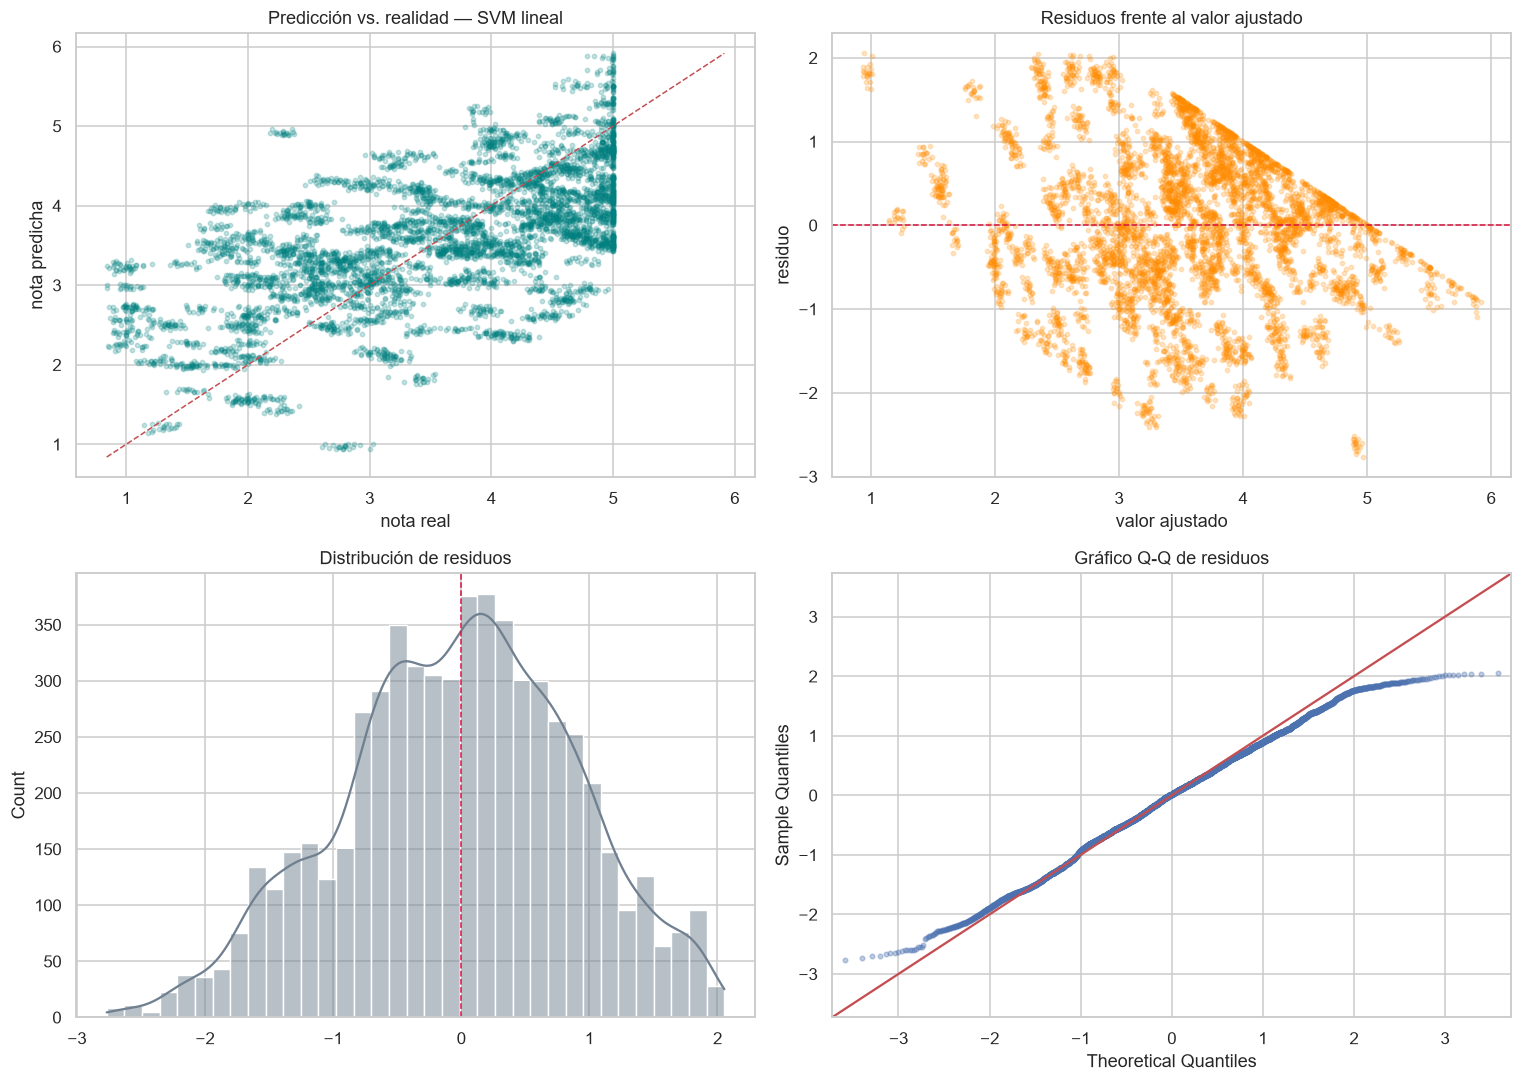

In [11]:
residuals = {}
residual_diagnostics = []

for name, pred in predictions.items():
    resid = y_test.to_numpy() - pred
    residuals[name] = resid
    sample = resid if len(resid) <= 5000 else np.random.default_rng(RANDOM_STATE).choice(resid, 5000, replace=False)
    normality = stats.normaltest(sample)
    if np.ptp(pred) > 1e-12:
        bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = het_breuschpagan(resid, sm.add_constant(pred))
    else:
        bp_f_pvalue = np.nan
    abs_resid_spearman = stats.spearmanr(np.abs(resid), pred).statistic
    residual_diagnostics.append({
        'modelo': name,
        'normaltest_p': normality.pvalue,
        'Breusch_Pagan_p': bp_f_pvalue,
        'Spearman_abs_resid_vs_ajustado': abs_resid_spearman,
        'media_residuo': resid.mean(),
        'desv_residuo': resid.std(),
    })

residual_diagnostics = pd.DataFrame(residual_diagnostics).set_index('modelo')
display(residual_diagnostics.round(5))

linear_resid = residuals['SVM lineal']
linear_pred = predictions['SVM lineal']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].scatter(y_test, linear_pred, s=8, alpha=0.22, color='teal')
lims = [min(y_test.min(), linear_pred.min()), max(y_test.max(), linear_pred.max())]
axes[0, 0].plot(lims, lims, 'r--', lw=1)
axes[0, 0].set_xlabel('nota real')
axes[0, 0].set_ylabel('nota predicha')
axes[0, 0].set_title('Predicción vs. realidad — SVM lineal')
axes[0, 1].scatter(linear_pred, linear_resid, s=8, alpha=0.22, color='darkorange')
axes[0, 1].axhline(0, color='crimson', linestyle='--', lw=1)
axes[0, 1].set_xlabel('valor ajustado')
axes[0, 1].set_ylabel('residuo')
axes[0, 1].set_title('Residuos frente al valor ajustado')
sns.histplot(linear_resid, kde=True, ax=axes[1, 0], color='slategray')
axes[1, 0].axvline(0, color='crimson', linestyle='--', lw=1)
axes[1, 0].set_title('Distribución de residuos')
qqplot(linear_resid, line='45', ax=axes[1, 1], marker='.', alpha=0.35)
axes[1, 1].set_title('Gráfico Q-Q de residuos')
plt.tight_layout()
plt.show()

La media del residuo del SVM es -0,0273, cercana a cero. Las pruebas de normalidad y Breusch–Pagan dan p < 0,001, indicando residuos no normales y heterocedásticos. La correlación de Spearman entre predicción y error absoluto es -0,1666, señal de errores mayores en los niveles predichos más bajos; los coeficientes no deben interpretarse como efectos inferenciales.

### 2.7 Curva de aprendizaje

La curva de aprendizaje compara el RMSE de entrenamiento y validación al aumentar el número de observaciones. Una brecha persistente sugiere sobreajuste; curvas que aún mejoran al final sugieren que más datos podrían aportar. Se calcula para el SVM lineal con el mismo esquema de folds estratificados.

,n_entrenamiento,RMSE_train_media,RMSE_train_sd,RMSE_validacion_media,RMSE_validacion_sd
0,2872,0.7973,0.0065,0.8059,0.0090
1,6942,0.8015,0.0041,0.8033,0.0076
2,11012,0.7975,0.0032,0.8013,0.0066
3,15082,0.7995,0.0018,0.8007,0.0058
4,19153,0.7982,0.0016,0.8002,0.0058


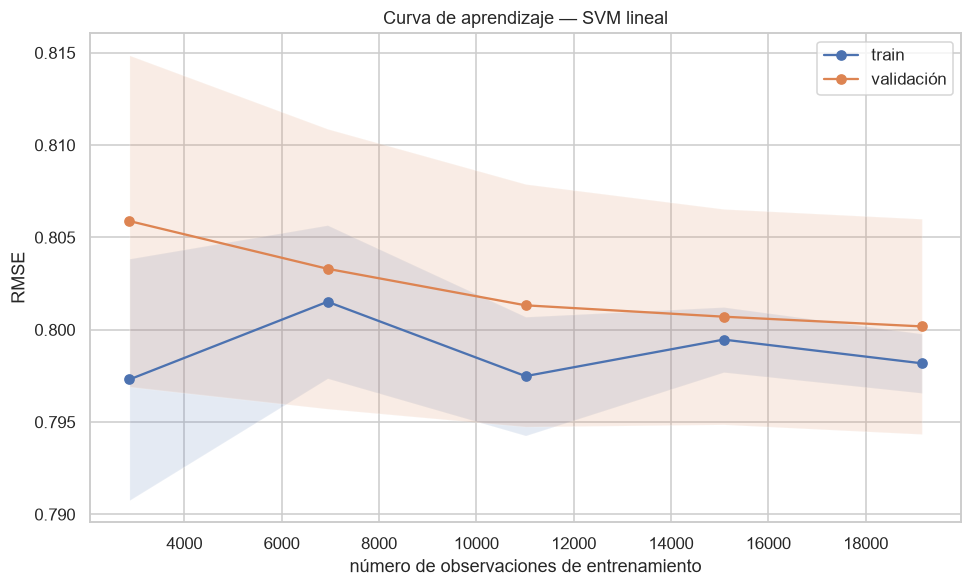

In [12]:
train_sizes, train_scores, validation_scores = learning_curve(
    linear_svm_pipeline,
    X_train,
    y_train,
    cv=cv_splits,
    scoring=make_scorer(rmse, greater_is_better=False),
    train_sizes=np.linspace(0.15, 1.0, 5),
    n_jobs=1,
)
train_rmse = -train_scores
validation_rmse = -validation_scores

learning_curve_table = pd.DataFrame({
    'n_entrenamiento': train_sizes,
    'RMSE_train_media': train_rmse.mean(axis=1),
    'RMSE_train_sd': train_rmse.std(axis=1),
    'RMSE_validacion_media': validation_rmse.mean(axis=1),
    'RMSE_validacion_sd': validation_rmse.std(axis=1),
})
display(learning_curve_table.round(4))

plt.figure(figsize=(9, 5.5))
plt.plot(train_sizes, learning_curve_table['RMSE_train_media'], marker='o', label='train')
plt.fill_between(
    train_sizes,
    learning_curve_table['RMSE_train_media'] - learning_curve_table['RMSE_train_sd'],
    learning_curve_table['RMSE_train_media'] + learning_curve_table['RMSE_train_sd'],
    alpha=0.15,
)
plt.plot(train_sizes, learning_curve_table['RMSE_validacion_media'], marker='o', label='validación')
plt.fill_between(
    train_sizes,
    learning_curve_table['RMSE_validacion_media'] - learning_curve_table['RMSE_validacion_sd'],
    learning_curve_table['RMSE_validacion_media'] + learning_curve_table['RMSE_validacion_sd'],
    alpha=0.15,
)
plt.xlabel('número de observaciones de entrenamiento')
plt.ylabel('RMSE')
plt.title('Curva de aprendizaje — SVM lineal')
plt.legend()
plt.tight_layout()
plt.show()

Con el mayor tamaño de entrenamiento evaluado (19.153 casos), el RMSE es 0,7982 en entrenamiento y 0,8002 en validación. La brecha interna es pequeña y la curva se aplana al crecer la muestra, mientras que el test mantiene un error mayor. Esto sugiere estabilidad dentro de los folds, con una brecha de generalización que debe seguirse evaluando.

### 2.8 Coeficientes e interpretación

Los coeficientes se interpretan en el espacio transformado. En variables numéricas representan el cambio esperado asociado con una desviación estándar de la variable después de `log1p` cuando corresponde. En variables categóricas representan la diferencia frente a la primera categoría usada como referencia por OneHotEncoder, manteniendo constantes las demás entradas. La magnitud debe leerse junto con la estabilidad de la métrica y la posible colinealidad entre variables derivadas.

Intercepto del SVM lineal: 1.69553
Coeficientes con mayor magnitud absoluta:


,coeficiente,abs_coeficiente
"cat__Categoria_temas_inicial_3 Plano de coordenadas, distancia y punto medio",-1.13365,1.13365
cat__Categoria_temas_final_3 Gráficos y funciones,-1.08881,1.08881
cat__avance_cuartiles_3 Avance superior a 29 temas,0.97752,0.97752
cat__programa_en_matricula_Arquitectura,0.96742,0.96742
cat__division_en_matricula_Escuela Arquitectura Urb y Dis,0.96742,0.96742
cat__Categoria_temas_final_2 Ecuaciones racionales que se reducen a lineales,0.94225,0.94225
cat__Categoria_temas_final_3 Temas Parcial 1 Cálculo I,0.82296,0.82296
num_plain__Dominio_Final,0.79232,0.79232
cat__Categoria_temas_final_4 Funciones polinómicas y racionales,-0.78742,0.78742
cat__Mat_Curso_Asignatura_Relacionada_MAT1100,0.77039,0.77039


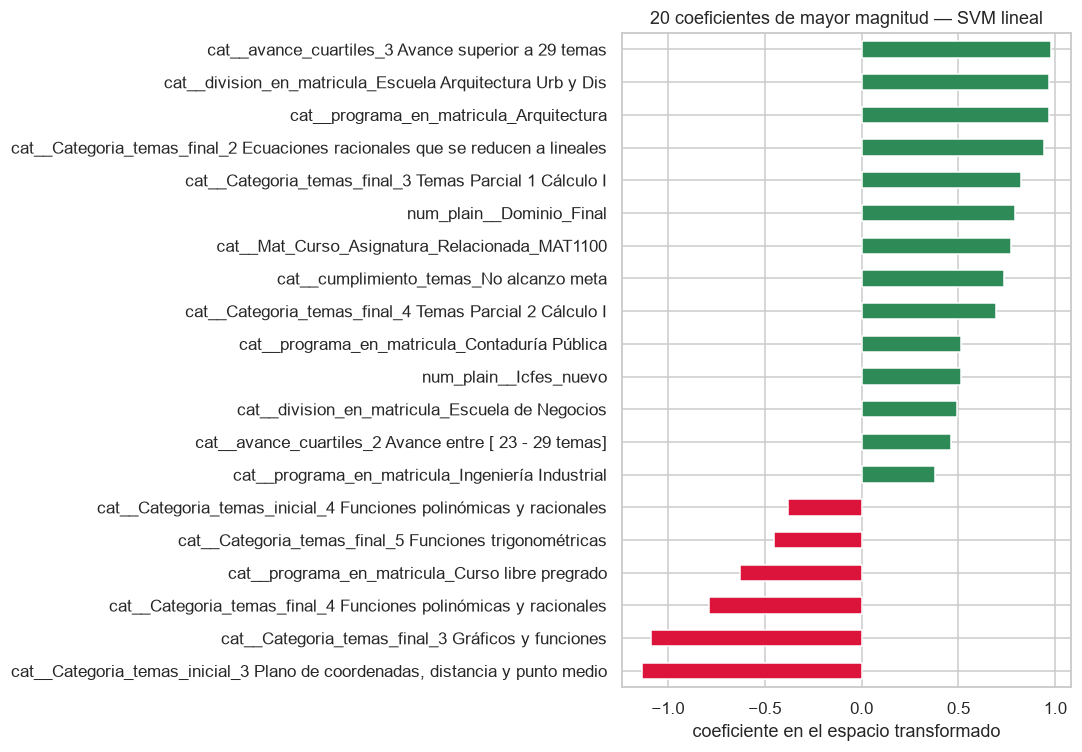

In [13]:
preprocessor_fitted = linear_svm_pipeline.named_steps['preprocesamiento']
linear_model = linear_svm_pipeline.named_steps['modelo']
transformed_names = preprocessor_fitted.get_feature_names_out()
coefficients = pd.Series(linear_model.coef_, index=transformed_names, name='coeficiente')
coefficient_table = coefficients.to_frame()
coefficient_table['abs_coeficiente'] = coefficient_table['coeficiente'].abs()
coefficient_table = coefficient_table.sort_values('abs_coeficiente', ascending=False)

print(f'Intercepto del SVM lineal: {linear_model.intercept_[0]:.5f}')
print('Coeficientes con mayor magnitud absoluta:')
display(coefficient_table.head(20).round(5))

fig, ax = plt.subplots(figsize=(10, 7))
top_coefficients = coefficient_table.head(20).sort_values('coeficiente')
colors = ['crimson' if value < 0 else 'seagreen' for value in top_coefficients['coeficiente']]
top_coefficients['coeficiente'].plot.barh(ax=ax, color=colors)
ax.set_title('20 coeficientes de mayor magnitud — SVM lineal')
ax.set_xlabel('coeficiente en el espacio transformado')
plt.tight_layout()
plt.show()

Los coeficientes de mayor magnitud corresponden principalmente a categorías de temas iniciales y finales, al avance por cuartiles y a categorías de programa/asignatura; también destaca Dominio_Final. En las variables categóricas, cada coeficiente expresa una diferencia frente a su categoría de referencia. Dada la redundancia entre variables de avance, categorías y contexto, las magnitudes y sus signos se interpretan junto con esa colinealidad y no como efectos causales independientes.

## Cierre del informe

El preprocesamiento excluye 58 registros de entrenamiento y 37 de prueba que incumplen las reglas de negocio; el ajuste usa 23.942 filas válidas de entrenamiento y la evaluación, 5.963 filas válidas de prueba. Los valores extremos que cumplen las reglas se conservan sin recorte. Las variables derivadas de reglas del curso o de agrupaciones período–asignatura se usan como columnas ya construidas porque no pueden reconstruirse de forma segura en esta etapa.

### Comparación del ajuste

En la ejecución validada, el SVM lineal fue claramente superior a la línea base Dummy en todas las métricas relevantes:

| Modelo | RMSE test | MAPE test | R² test | MAE test |
|---|---:|---:|---:|---:|
| Dummy media | 1.1282 | 37.7330 % | -0.0000 | 0.9705 |
| SVM lineal | 0.9093 | 27.1489 % | 0.3503 | 0.7329 |

La Dummy obtiene un R² prácticamente igual a cero, como se espera de un predictor que solo devuelve la media del train. En el test, el SVM reduce el RMSE en 19.40 % y el MAPE en 28.05 % frente a la Dummy, y alcanza un R² de 0.3503. Las variables académicas y de contexto contienen señal predictiva, y el **SVM lineal supera a la línea base**.

### Qué tan bueno fue el ajuste

El ajuste debe calificarse como **moderado**. En el test, el RMSE fue de 0.9093 puntos y el MAE de 0.7329 puntos de nota, en una escala de 0.5 a 5.0. El R² de 0.3503 indica que el modelo explica cerca del 35.0 % de la variabilidad observada; el resto no queda explicado por esta representación lineal. `LinearSVR` no impone límites a la nota predicha, así que algunas predicciones podrían quedar fuera del intervalo observado de 0.5 a 5.0.

El MAPE de 27.1489 % complementa la lectura, pero no debe ser la única métrica: al existir notas bajas, errores absolutos pequeños pueden convertirse en porcentajes relativamente grandes. Por eso RMSE y MAE son más informativos para juzgar el error en la escala académica.

Los intervalos bootstrap del 95 % para el SVM fueron RMSE [0.8929, 0.9235], MAPE [26.2389 %, 28.0514 %] y R² [0.3275, 0.3715]. Describen la incertidumbre de las métricas en esta muestra de prueba y no sustituyen una evaluación externa.

### Generalización y posible razón del desempeño

En validación cruzada, el SVM obtuvo RMSE medio = 0.8001 (desviación = 0.0058) y R² medio = 0.4981 (desviación = 0.0100); en el test obtuvo RMSE = 0.9093 y R² = 0.3503. El menor desempeño en el test indica una brecha de generalización respecto de la validación interna. La curva de aprendizaje mostró una diferencia pequeña entre entrenamiento y validación con el mayor tamaño evaluado (RMSE = 0.7982 y 0.8002, respectivamente). No hay una brecha interna marcada, aunque la caída en el test requiere cautela.

Una posible explicación es una combinación de tres factores. Primero, la nota depende de factores no observados en estas columnas, como asistencia, motivación, condiciones de evaluación, acompañamiento docente o hábitos de estudio. Segundo, un SVM lineal solo representa efectos aditivos en el espacio transformado; no captura completamente interacciones o umbrales entre avance, dominios, tiempos y asignaturas. Tercero, la partición externa fue agrupada por estudiante, pero el identificador no está disponible para construir folds agrupados dentro del train. Como los datos fueron aumentados, variantes cercanas de un mismo registro pueden quedar en folds distintos y hacer que la validación cruzada interna sea algo más optimista que el test independiente. Esta última explicación es una hipótesis metodológica que debe confirmarse conservando el identificador de estudiante en una futura validación.

### Diagnóstico de residuos y decisión final

La media del residuo del SVM fue -0.0273, cercana a cero. Las pruebas de normalidad y Breusch–Pagan dieron p < 0.001, señal de residuos no normales y heterocedásticos. La correlación de Spearman entre el residuo absoluto y el valor ajustado fue -0.1666, lo que indica que la magnitud del error tiende a ser mayor en los niveles predichos más bajos. Por ello, los coeficientes y los intervalos deben interpretarse con cautela; este modelo es una referencia predictiva, no una herramienta de inferencia clásica.

En conclusión, el SVM lineal es una base sólida frente a la predicción constante y demuestra que las variables disponibles contienen señal útil. Su capacidad predictiva es intermedia: sirve como modelo base interpretable y como punto de comparación, pero no debe considerarse todavía un modelo final de alta precisión. La mejora posterior más razonable sería evaluar modelos capaces de representar no linealidades e interacciones, manteniendo la misma disciplina de partición, preprocesamiento dentro de Pipeline y validación agrupada por estudiante cuando el identificador pueda conservarse.